# EAST + CRAFT Greedy Merge Ensemble

## Setup & Imports

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
from shapely.geometry import Polygon
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Torchvision compatibility patch
import torchvision.models.vgg as vgg_module
if not hasattr(vgg_module, 'model_urls'):
    vgg_module.model_urls = {
        'vgg16_bn': 'https://download.pytorch.org/models/vgg16_bn-6c64b313.pth'
    }

from craft_text_detector import Craft
from craft_text_detector.predict import get_prediction
import craft_text_detector.craft_utils as craft_utils

# CRAFT numpy compatibility patches
def patched_adjustResultCoordinates(polys, ratio_w, ratio_h, ratio_net=2):
    if len(polys) > 0:
        for k in range(len(polys)):
            if polys[k] is not None:
                polys[k] *= (ratio_w * ratio_net, ratio_h * ratio_net)
    return polys

craft_utils.adjustResultCoordinates = patched_adjustResultCoordinates

_original_np_array = np.array
def _patched_np_array(arr_input, dtype=None, **kwargs):
    try:
        return _original_np_array(arr_input, dtype=dtype, **kwargs)
    except ValueError as e:
        if "inhomogeneous shape" in str(e) or "setting an array element" in str(e):
            return _original_np_array(arr_input, dtype=object)
        raise
np.array = _patched_np_array

# Set paths
EAST_MODEL_PATH = 'pretrained_weights/east/frozen_east_text_detection.pb'
CRAFT_MODEL_PATH = 'pretrained_weights/craft/craft_ic15_20k.pth'
IMAGES_DIR = Path('archive/ch4_test_images')
GT_DIR = Path('archive/ch4_test_localization_transcription_gt')
OUTPUT_DIR = Path('greedyfuse1_outputs')
VIZ_DIR = Path('greedyfuse1_visualizations')

# Create output directories
for dir_path in [OUTPUT_DIR / 'east', OUTPUT_DIR / 'craft', OUTPUT_DIR / 'ensemble', VIZ_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

print("Setup complete")
print(f"Images: {len(list(IMAGES_DIR.glob('*.jpg')))} files")
print(f"Output: {OUTPUT_DIR}")

c:\Users\ASUS\anaconda3\envs\.py38\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete
Images: 500 files
Output: greedyfuse1_outputs


## Load EAST Model

In [6]:
# EAST Configuration (Optimized for this model - from east-fin-1)
TARGET_DIM = 1280
CONFIDENCE_THRESH = 0.8
NMS_THRESH = 0.2
MEAN_VALS = (123.68, 116.78, 103.94)

EAST_OUTPUT_LAYERS = [
    "feature_fusion/Conv_7/Sigmoid",
    "feature_fusion/concat_3"
]

east_net = cv2.dnn.readNet(EAST_MODEL_PATH)
print(f"EAST model loaded from {EAST_MODEL_PATH}")

EAST model loaded from pretrained_weights/east/frozen_east_text_detection.pb


## Load CRAFT Model

In [7]:
# CRAFT Configuration (Optimized for this model - from craft.fin.2)
craft_detector = Craft(
    crop_type="poly",
    text_threshold=0.52,
    link_threshold=0.4,
    low_text=0.3,
    long_size=2240,
    cuda=torch.cuda.is_available()
)

# Load custom weights
if Path(CRAFT_MODEL_PATH).exists():
    state_dict = torch.load(CRAFT_MODEL_PATH, map_location='cpu')
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('module.'):
            new_state_dict[key[7:]] = value
        else:
            new_state_dict[key] = value
    craft_detector.craft_net.load_state_dict(new_state_dict)
    print(f"CRAFT model loaded from {CRAFT_MODEL_PATH}")
else:
    print("CRAFT model loaded with default weights")

CRAFT model loaded from pretrained_weights/craft/craft_ic15_20k.pth


## EAST Inference Function

In [8]:
def letterbox_image(image, target_dim=TARGET_DIM):
    """Resize with aspect ratio preservation and pad to multiple of 32"""
    orig_h, orig_w = image.shape[:2]
    longest_side = max(orig_h, orig_w)
    scale = target_dim / float(longest_side)
    
    new_w = int(round(orig_w * scale))
    new_h = int(round(orig_h * scale))
    resized = cv2.resize(image, (new_w, new_h))
    
    pad_w = (32 - (new_w % 32)) % 32
    pad_h = (32 - (new_h % 32)) % 32
    padded_w = new_w + pad_w
    padded_h = new_h + pad_h
    
    padded = np.zeros((padded_h, padded_w, 3), dtype=resized.dtype)
    padded[0:new_h, 0:new_w] = resized
    
    return padded, scale, pad_w, pad_h, orig_h, orig_w

def decode_rotated_predictions(scores, geometry, conf_threshold):
    """Decode EAST output into rotated rectangles"""
    height = scores.shape[2]
    width = scores.shape[3]
    
    boxes = []
    confidences = []
    
    for y in range(height):
        scores_data = scores[0, 0, y]
        x0_data = geometry[0, 0, y]
        x1_data = geometry[0, 1, y]
        x2_data = geometry[0, 2, y]
        x3_data = geometry[0, 3, y]
        angles_data = geometry[0, 4, y]
        
        for x in range(width):
            score = scores_data[x]
            if score < conf_threshold:
                continue
            
            angle = angles_data[x]
            cos_a = np.cos(angle)
            sin_a = np.sin(angle)
            
            h = x0_data[x] + x2_data[x]
            w = x1_data[x] + x3_data[x]
            
            offset_x = x * 4.0
            offset_y = y * 4.0
            
            offset = (
                offset_x + cos_a * x1_data[x] + sin_a * x2_data[x],
                offset_y - sin_a * x1_data[x] + cos_a * x2_data[x],
            )
            
            p1x = -sin_a * h + offset[0]
            p1y = -cos_a * h + offset[1]
            p3x = -cos_a * w + offset[0]
            p3y = sin_a * w + offset[1]
            
            cx = 0.5 * (p1x + p3x)
            cy = 0.5 * (p1y + p3y)
            angle_deg = -angle * 180.0 / np.pi
            
            boxes.append(((cx, cy), (w, h), angle_deg))
            confidences.append(float(score))
    
    return boxes, confidences

def map_rotated_boxes_to_original(boxes, indices, scale, pad_w, pad_h, orig_w, orig_h):
    """Map rotated boxes back to original image coordinates"""
    polygons = []
    if len(indices) == 0:
        return polygons
    
    if hasattr(indices, "flatten"):
        indices = indices.flatten()
    
    for idx in indices:
        rot_rect = boxes[idx]
        pts = cv2.boxPoints(rot_rect)
        pts[:, 0] /= scale
        pts[:, 1] /= scale
        pts[:, 0] = np.clip(pts[:, 0], 0, orig_w - 1)
        pts[:, 1] = np.clip(pts[:, 1], 0, orig_h - 1)
        polygons.append(pts.astype(np.float32))
    
    return polygons

def detect_east(image_path, net):
    """Run EAST text detection on an image"""
    image = cv2.imread(str(image_path))
    padded, scale, pad_w, pad_h, orig_h, orig_w = letterbox_image(image, TARGET_DIM)
    
    h, w = padded.shape[:2]
    blob = cv2.dnn.blobFromImage(padded, 1.0, (w, h), MEAN_VALS, swapRB=True, crop=False)
    net.setInput(blob)
    scores, geometry = net.forward(EAST_OUTPUT_LAYERS)
    
    boxes, confidences = decode_rotated_predictions(scores, geometry, CONFIDENCE_THRESH)
    indices = cv2.dnn.NMSBoxesRotated(boxes, confidences, CONFIDENCE_THRESH, NMS_THRESH)
    
    polygons = map_rotated_boxes_to_original(boxes, indices, scale, pad_w, pad_h, orig_w, orig_h)
    
    kept_confidences = []
    if len(indices) > 0 and hasattr(indices, "flatten"):
        for idx in indices.flatten():
            kept_confidences.append(confidences[idx])
    
    detections = list(zip(polygons, kept_confidences))
    return detections

print("EAST inference function ready")

EAST inference function ready


## CRAFT Inference Function

In [9]:
def detect_craft(image_path, craft_detector):
    """Run CRAFT text detection on an image with proper confidence scores"""
    img = cv2.imread(str(image_path))
    
    # Get raw prediction with score maps
    prediction = get_prediction(
        image=img,
        craft_net=craft_detector.craft_net,
        refine_net=None,
        text_threshold=craft_detector.text_threshold,
        link_threshold=craft_detector.link_threshold,
        low_text=craft_detector.low_text,
        cuda=craft_detector.cuda,
        long_size=craft_detector.long_size,
        poly=True
    )
    
    pred_boxes = prediction["boxes"]
    text_map = prediction["heatmaps"]["text_score_heatmap"]
    
    detections = []
    for box in pred_boxes:
        polygon = box.astype(np.int32)
        
        # Compute mean text score from heatmap
        h, w = text_map.shape[:2]
        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.fillPoly(mask, [polygon], 1)
        
        if mask.sum() > 0:
            score = float(text_map[mask == 1].mean())
        else:
            score = 0.9
        
        detections.append((polygon.astype(np.float32), score))
    
    return detections

print("CRAFT inference function ready")

CRAFT inference function ready


## Run EAST Inference on All Images

In [6]:
def save_detections(detections, output_path):
    """Save detections to file in format: x1,y1,x2,y2,x3,y3,x4,y4,confidence"""
    with open(output_path, 'w') as f:
        for polygon, conf in detections:
            coords = ','.join([str(int(c)) for point in polygon for c in point])
            f.write(f"{coords},{conf:.4f}\n")

# Run EAST on all images
print("Running EAST inference...")
east_results = {}
image_files = sorted(IMAGES_DIR.glob('*.jpg')) + sorted(IMAGES_DIR.glob('*.png'))

for img_path in tqdm(image_files, desc="EAST"):
    detections = detect_east(img_path, east_net)
    east_results[img_path.stem] = detections
    output_path = OUTPUT_DIR / 'east' / f"{img_path.stem}.txt"
    save_detections(detections, output_path)

print(f"EAST inference complete: {len(east_results)} images processed")

Running EAST inference...


EAST: 100%|██████████| 500/500 [08:47<00:00,  1.05s/it]

EAST inference complete: 500 images processed


## Run CRAFT Inference on All Images

In [7]:
# Run CRAFT on all images
print("Running CRAFT inference...")
craft_results = {}

for img_path in tqdm(image_files, desc="CRAFT"):
    detections = detect_craft(img_path, craft_detector)
    craft_results[img_path.stem] = detections
    output_path = OUTPUT_DIR / 'craft' / f"{img_path.stem}.txt"
    save_detections(detections, output_path)

print(f"CRAFT inference complete: {len(craft_results)} images processed")

Running CRAFT inference...


CRAFT: 100%|██████████| 500/500 [1:31:27<00:00, 10.97s/it]

CRAFT inference complete: 500 images processed


## Greedy Merge Ensemble

In [13]:
def polygon_iou(poly1, poly2):
    """Calculate IoU between two polygons using Shapely"""
    try:
        p1 = Polygon(poly1)
        p2 = Polygon(poly2)
        
        if not p1.is_valid:
            p1 = p1.buffer(0)
        if not p2.is_valid:
            p2 = p2.buffer(0)
        
        intersection = p1.intersection(p2).area
        union = p1.union(p2).area
        
        if union == 0:
            return 0.0
        
        return intersection / union
    except:
        return 0.0

def greedy_merge(east_detections, craft_detections, iou_threshold=0.3, confidence_threshold=0.5):
    """
    Improved greedy merge algorithm with better duplicate handling
    
    Strategy:
    1. Match EAST and CRAFT boxes with lower IoU threshold (0.3)
    2. Average coordinates for matched pairs
    3. Only keep high-confidence unmatched boxes (conf > threshold)
    4. Apply final NMS to remove remaining duplicates
    """
    merged = []
    used_craft = set()
    
    # Step 1: Match EAST boxes with CRAFT boxes (lower threshold for better matching)
    for east_poly, east_conf in east_detections:
        best_iou = 0
        best_match_idx = -1
        
        for craft_idx, (craft_poly, craft_conf) in enumerate(craft_detections):
            if craft_idx in used_craft:
                continue
            
            iou = polygon_iou(east_poly, craft_poly)
            if iou > best_iou:
                best_iou = iou
                best_match_idx = craft_idx
        
        if best_iou >= iou_threshold:
            # Merge matched boxes
            craft_poly, craft_conf = craft_detections[best_match_idx]
            used_craft.add(best_match_idx)
            merged_poly = ((east_poly.astype(float) + craft_poly.astype(float)) / 2).astype(np.float32)
            merged_conf = max(east_conf, craft_conf)
            merged.append((merged_poly, merged_conf))
        else:
            # Only keep high-confidence unmatched EAST boxes
            if east_conf >= confidence_threshold:
                merged.append((east_poly, east_conf))
    
    # Step 2: Only add high-confidence unmatched CRAFT boxes
    for craft_idx, (craft_poly, craft_conf) in enumerate(craft_detections):
        if craft_idx not in used_craft and craft_conf >= confidence_threshold:
            merged.append((craft_poly, craft_conf))
    
    # Step 3: Apply final NMS to remove any remaining duplicates
    merged = apply_nms_to_polygons(merged, iou_threshold=0.3)
    
    return merged

def apply_nms_to_polygons(detections, iou_threshold=0.3):
    """Apply NMS to polygon detections"""
    if len(detections) == 0:
        return []
    
    # Sort by confidence (descending)
    detections = sorted(detections, key=lambda x: x[1], reverse=True)
    
    keep = []
    suppressed = set()
    
    for i, (poly_i, conf_i) in enumerate(detections):
        if i in suppressed:
            continue
        
        keep.append((poly_i, conf_i))
        
        # Suppress overlapping lower-confidence boxes
        for j in range(i + 1, len(detections)):
            if j in suppressed:
                continue
            
            poly_j, conf_j = detections[j]
            iou = polygon_iou(poly_i, poly_j)
            
            if iou >= iou_threshold:
                suppressed.add(j)
    
    return keep

print("Improved greedy merge function ready")

Improved greedy merge function ready


## Run Greedy Merge on All Images

In [9]:
# Run greedy merge
print("Running greedy merge ensemble...")
ensemble_results = {}

for img_stem in tqdm(east_results.keys(), desc="Ensemble"):
    east_dets = east_results[img_stem]
    craft_dets = craft_results[img_stem]
    merged_dets = greedy_merge(east_dets, craft_dets)
    ensemble_results[img_stem] = merged_dets
    output_path = OUTPUT_DIR / 'ensemble' / f"{img_stem}.txt"
    save_detections(merged_dets, output_path)

print(f"Greedy merge complete: {len(ensemble_results)} images processed")

Running greedy merge ensemble...


Ensemble: 100%|██████████| 500/500 [00:06<00:00, 76.00it/s] 

Greedy merge complete: 500 images processed


## Evaluation Functions

In [10]:
def load_ground_truth(gt_path):
    """Load ground truth annotations (ICDAR format) - separates care and don't-care regions"""
    care_polygons = []
    dontcare_polygons = []
    
    if not gt_path.exists():
        return care_polygons, dontcare_polygons
    
    with open(gt_path, 'r', encoding='utf-8-sig') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            
            parts = line.split(',')
            if len(parts) >= 8:
                try:
                    coords = [int(float(x)) for x in parts[:8]]
                    polygon = np.array([
                        [coords[0], coords[1]],
                        [coords[2], coords[3]],
                        [coords[4], coords[5]],
                        [coords[6], coords[7]]
                    ])
                    
                    # Separate care and don't-care regions
                    if len(parts) > 8 and parts[8].strip() == '###':
                        dontcare_polygons.append(polygon)
                    else:
                        care_polygons.append(polygon)
                except ValueError:
                    continue
    
    return care_polygons, dontcare_polygons

def evaluate_detections(detections_dict, gt_dir, iou_threshold=0.5):
    """Evaluate detections against ground truth using proper ICDAR protocol"""
    total_gt = 0
    total_det = 0
    total_tp = 0
    
    for img_stem, detections in detections_dict.items():
        gt_path = gt_dir / f"gt_{img_stem}.txt"
        care_polygons, dontcare_polygons = load_ground_truth(gt_path)
        
        total_gt += len(care_polygons)
        
        matched_gt = set()
        
        for det_poly, det_conf in detections:
            # Check if detection overlaps with don't-care region
            is_dontcare = False
            for dc_poly in dontcare_polygons:
                if polygon_iou(det_poly, dc_poly) >= iou_threshold:
                    is_dontcare = True
                    break
            
            if is_dontcare:
                # Don't count detections on don't-care regions
                continue
            
            # Count this detection
            total_det += 1
            
            # Try to match with ground truth
            for gt_idx, gt_poly in enumerate(care_polygons):
                if gt_idx in matched_gt:
                    continue
                
                iou = polygon_iou(det_poly, gt_poly)
                if iou >= iou_threshold:
                    matched_gt.add(gt_idx)
                    total_tp += 1
                    break
    
    precision = total_tp / total_det if total_det > 0 else 0
    recall = total_tp / total_gt if total_gt > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'true_positives': total_tp,
        'total_detections': total_det,
        'total_ground_truth': total_gt
    }

print("Evaluation functions ready (FIXED: proper ICDAR don't-care handling)")

Evaluation functions ready (FIXED: proper ICDAR don't-care handling)


## Evaluate All Methods

In [11]:
print("\n" + "="*60)
print("EVALUATION RESULTS")
print("="*60)

print("\nEvaluating EAST...")
east_metrics = evaluate_detections(east_results, GT_DIR)

print("Evaluating CRAFT...")
craft_metrics = evaluate_detections(craft_results, GT_DIR)

print("Evaluating Ensemble (Greedy Merge)...")
ensemble_metrics = evaluate_detections(ensemble_results, GT_DIR)

print("\nEvaluation complete")


EVALUATION RESULTS

Evaluating EAST...
Evaluating CRAFT...
Evaluating Ensemble (Greedy Merge)...

Evaluation complete


## Display Results Table

In [12]:
# Print results table
print("\n" + "="*80)
print("PERFORMANCE COMPARISON")
print("="*80)
print(f"{'Method':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Detections':<12}")
print("-"*80)

for method_name, metrics in [('EAST', east_metrics), 
                              ('CRAFT', craft_metrics), 
                              ('Ensemble (Greedy)', ensemble_metrics)]:
    print(f"{method_name:<20} {metrics['precision']:<12.4f} {metrics['recall']:<12.4f} "
          f"{metrics['f1_score']:<12.4f} {metrics['total_detections']:<12}")

print("-"*80)
print(f"Total Ground Truth Instances: {east_metrics['total_ground_truth']}")
print("="*80)

# Calculate improvements
print("\nIMPROVEMENTS:")
print("-"*80)
if east_metrics['f1_score'] > 0:
    improvement_over_east = ((ensemble_metrics['f1_score'] - east_metrics['f1_score']) / 
                              east_metrics['f1_score'] * 100)
    print(f"Ensemble vs EAST:  {improvement_over_east:+.2f}% F1-score improvement")

if craft_metrics['f1_score'] > 0:
    improvement_over_craft = ((ensemble_metrics['f1_score'] - craft_metrics['f1_score']) / 
                               craft_metrics['f1_score'] * 100)
    print(f"Ensemble vs CRAFT: {improvement_over_craft:+.2f}% F1-score improvement")
print("="*80)


PERFORMANCE COMPARISON
Method               Precision    Recall       F1-Score     Detections  
--------------------------------------------------------------------------------
EAST                 0.6799       0.7251       0.7018       2215        
CRAFT                0.6521       0.7309       0.6892       2328        
Ensemble (Greedy)    0.4164       0.6211       0.4986       3098        
--------------------------------------------------------------------------------
Total Ground Truth Instances: 2077

IMPROVEMENTS:
--------------------------------------------------------------------------------
Ensemble vs EAST:  -28.96% F1-score improvement
Ensemble vs CRAFT: -27.66% F1-score improvement


## Visualization Functions

In [11]:
def draw_detections(image, detections, color=(0, 255, 0), thickness=2):
    """Draw detections on image"""
    img_copy = image.copy()
    for polygon, conf in detections:
        pts = polygon.reshape((-1, 1, 2)).astype(np.int32)
        cv2.polylines(img_copy, [pts], isClosed=True, color=color, thickness=thickness)
    return img_copy

def create_comparison_visualization(img_path, east_dets, craft_dets, ensemble_dets, output_path):
    """Create 3-row comparison visualization"""
    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    img_east = draw_detections(image, east_dets, color=(255, 0, 0), thickness=2)
    img_craft = draw_detections(image, craft_dets, color=(0, 0, 255), thickness=2)
    img_ensemble = draw_detections(image, ensemble_dets, color=(0, 255, 0), thickness=2)
    
    fig, axes = plt.subplots(3, 1, figsize=(15, 18))
    
    axes[0].imshow(img_east)
    axes[0].set_title(f'EAST Detection ({len(east_dets)} boxes)', fontsize=16, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(img_craft)
    axes[1].set_title(f'CRAFT Detection ({len(craft_dets)} boxes)', fontsize=16, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(img_ensemble)
    axes[2].set_title(f'Ensemble (Greedy Merge) ({len(ensemble_dets)} boxes)', 
                      fontsize=16, fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close()
    
    print(f"  Saved: {output_path.name}")

print("Visualization functions ready")

Visualization functions ready


## Generate Comparison Visualizations

In [14]:
print("\nGenerating comparison visualizations...")
print("="*60)

num_visualizations = min(5, len(image_files))

for img_path in image_files[:num_visualizations]:
    img_stem = img_path.stem
    print(f"Creating visualization for {img_path.name}...")
    output_path = VIZ_DIR / f"{img_stem}_comparison.png"
    create_comparison_visualization(
        img_path,
        east_results[img_stem],
        craft_results[img_stem],
        ensemble_results[img_stem],
        output_path
    )

print("="*60)
print(f"Generated {num_visualizations} comparison visualizations")
print(f"Saved to: {VIZ_DIR}")


Generating comparison visualizations...
Creating visualization for img_1.jpg...
  Saved: img_1_comparison.png
Creating visualization for img_10.jpg...
  Saved: img_10_comparison.png
Creating visualization for img_100.jpg...
  Saved: img_100_comparison.png
Creating visualization for img_101.jpg...
  Saved: img_101_comparison.png
Creating visualization for img_102.jpg...
  Saved: img_102_comparison.png
Generated 5 comparison visualizations
Saved to: greedyfuse1_visualizations


## Display Sample Visualizations

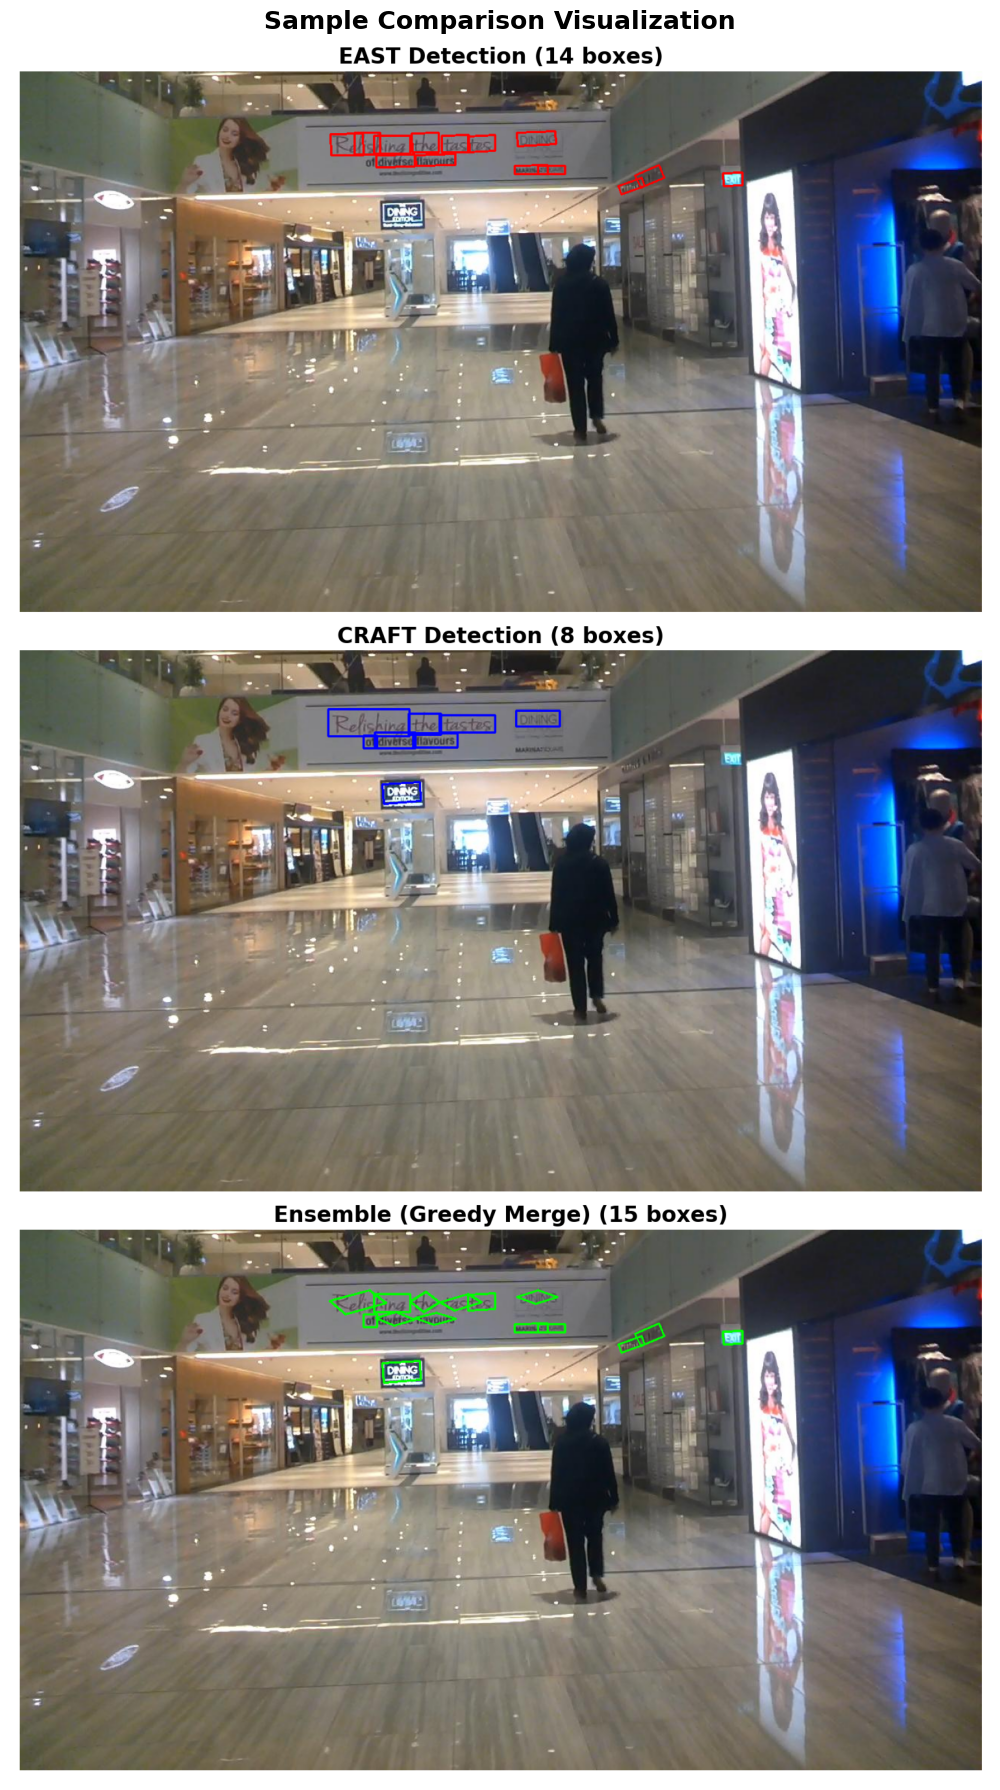


Displaying: img_100_comparison.png
All visualizations saved to: greedyfuse1_visualizations


In [15]:
# Display first visualization
viz_files = sorted(VIZ_DIR.glob('*.png'))
if len(viz_files) > 0:
    sample_viz = viz_files[0]
    img = plt.imread(sample_viz)
    
    plt.figure(figsize=(15, 18))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Sample Comparison Visualization', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\nDisplaying: {sample_viz.name}")
    print(f"All visualizations saved to: {VIZ_DIR}")


Processing: test.jpeg
----------------------------------------
Running EAST detections...
Running CRAFT detections...
Running greedy merge ensemble...
----------------------------------------
Greedy Merge found 76 final boxes
----------------------------------------
Saved perfectly borderless image: test_greedymerge.png



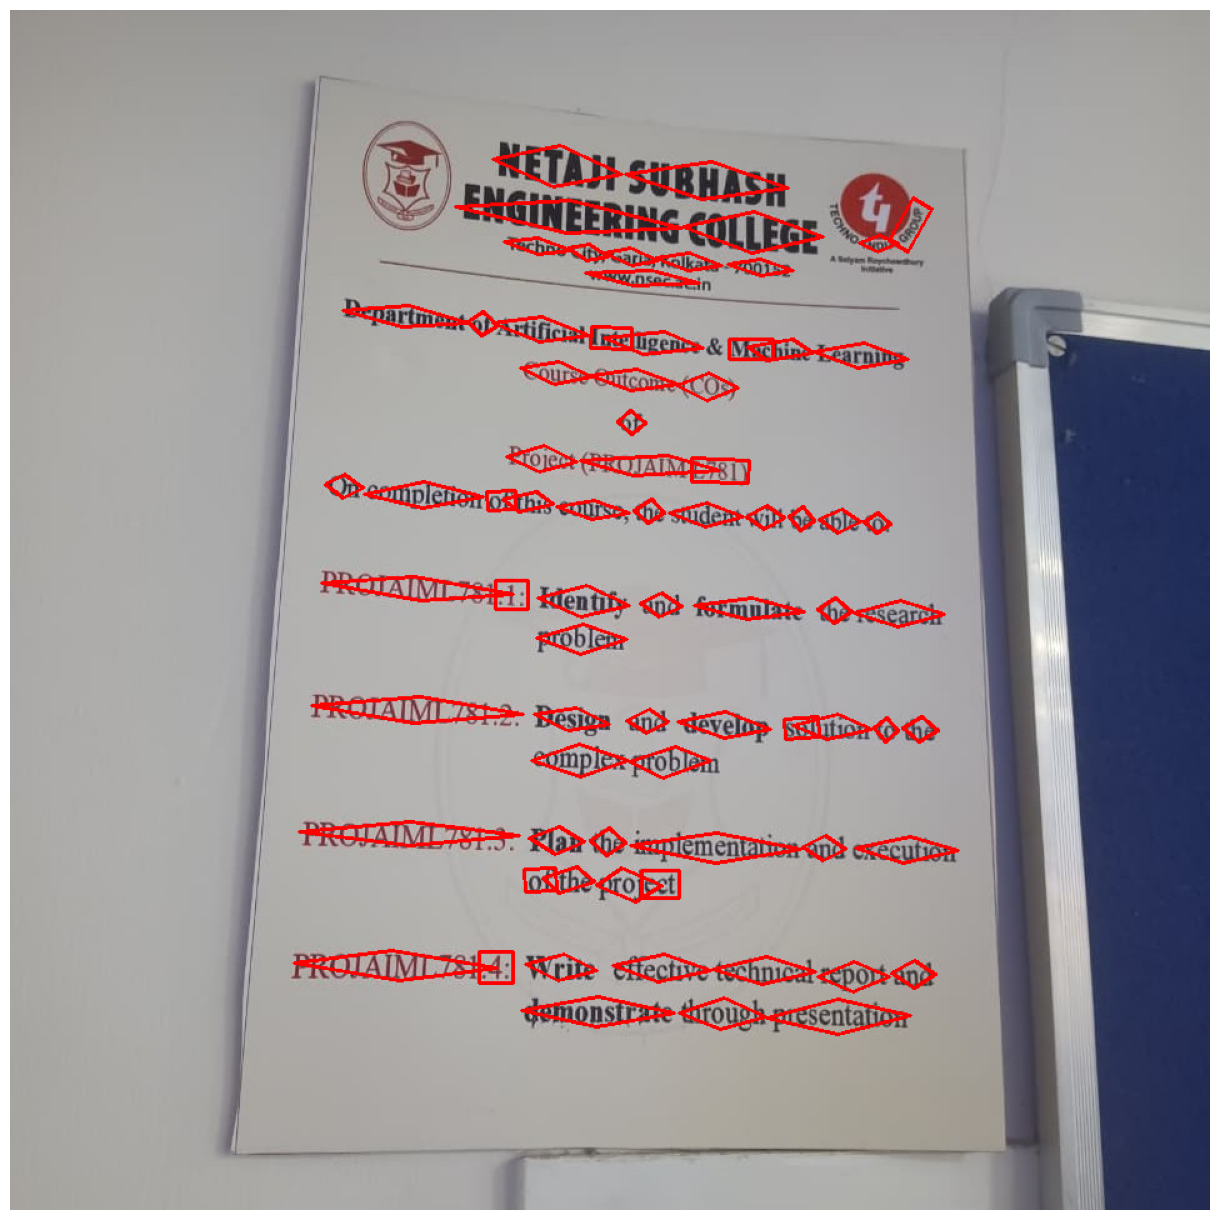

In [33]:
# ============================================================
# Single Image Test - Visualize Greedy Merge Only
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def test_single_image_greedy(image_path):
    """
    Test a single image and visualize ONLY the greedy merge results in red.
    """
    image_path = Path(image_path)
    
    if not image_path.exists():
        print(f"Error: Image not found at {image_path}")
        return
    
    # Load image
    img = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    print(f"\nProcessing: {image_path.name}")
    print("-" * 40)
    
    # Run EAST detection
    print("Running EAST detections...")
    east_dets = detect_east(image_path, east_net)
    
    # Run CRAFT detection
    print("Running CRAFT detections...")
    craft_dets = detect_craft(image_path, craft_detector)
    
    # Run Greedy Merge Ensemble
    print("Running greedy merge ensemble...")
    greedy_dets = greedy_merge(east_dets, craft_dets)
    
    print("-" * 40)
    print(f"Greedy Merge found {len(greedy_dets)} final boxes")
    print("-" * 40)
    
    # Define RED color for matplotlib (RGB)
    RED = (255, 0, 0)
    
    def draw_boxes(img, detections, color, thickness=2):
        """Draw bounding boxes on image"""
        img_copy = img.copy()
        for poly, conf in detections:
            pts = poly.astype(np.int32).reshape((-1, 1, 2))
            cv2.polylines(img_copy, [pts], isClosed=True, color=color, thickness=thickness)
            
            # NOTE: Confidence scores are commented out for publication clarity.
            # If you need them for debugging, uncomment the next two lines.
            # x, y = int(poly[0][0]), int(poly[0][1]) - 5
            # cv2.putText(img_copy, f'{conf:.2f}', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
            
        return img_copy

    # Draw only the greedy detections
    final_img = draw_boxes(img_rgb, greedy_dets, RED, thickness=2)
    
    # Calculate dynamic figure size to match image aspect ratio perfectly
    H, W = img_rgb.shape[:2]
    fig_w = 12
    fig_h = fig_w * (H / W)
    
    # --- UPDATED PLOTTING CODE FOR ZERO BORDER ---
    
    # 1. Create the figure without a frame
    fig = plt.figure(figsize=(fig_w, fig_h), frameon=False)
    
    # 2. Add an axis that exactly fills the figure from edge to edge [left, bottom, width, height]
    ax = fig.add_axes([0, 0, 1, 1])
    ax.imshow(final_img)
    ax.axis('off')
    
    save_name = f"{image_path.stem}_greedymerge.png"
    
    # 3. Save with pad_inches exactly at 0
    plt.savefig(save_name, dpi=300, bbox_inches='tight', pad_inches=0, facecolor='white') 
    print(f"Saved perfectly borderless image: {save_name}\n")
    plt.show()
    
    return greedy_dets

# ============================================================
# TEST YOUR IMAGE HERE
# ============================================================

test_image = 'test.jpeg'
greedy_dets = test_single_image_greedy(test_image)